In [ ]:
! pip install category_encoders

In [ ]:
! pip install lightgbm --upgrade

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available — skipping")
try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not available — skipping")

In [ ]:
class TargetEncoder:
    def __init__(self, cols, smoothing=10):
        self.cols= cols
        self.smoothing = smoothing
        self.mapping   = {}
        self.global_mean = {}
    def fit_transform(self, X, y):
        X = X.copy()
        for col in self.cols:
            self.global_mean[col] = y.mean()
            stats = y.groupby(X[col]).agg(['mean','count'])
            smooth = (stats['count'] * stats['mean'] + self.smoothing * self.global_mean[col]) \
                     / (stats['count'] + self.smoothing)
            self.mapping[col] = smooth
            X[col] = X[col].map(smooth).fillna(self.global_mean[col])
        return X
    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.mapping[col]).fillna(self.global_mean[col])
        return X

In [3]:
df = pd.read_excel("Tension.xlsx")
df = df.drop(columns=['Mixture', 'Specimen', 'Coarse Aggr.', 'Shape Factor'])
df = df.dropna(subset=['Fiber Type'])
df = df.reset_index(drop=True)
print("=" * 65)
print("  BASELINE MODEL COMPARISON — STRESS & STRAIN")
print("=" * 65)
print(f"  Dataset shape : {df.shape}")
print(f"  Features      : {df.shape[1] - 2}")

  BASELINE MODEL COMPARISON — STRESS & STRAIN
  Dataset shape : (503, 20)
  Features      : 18


In [4]:
feature_cols = [c for c in df.columns if c not in ['Second Stress', 'Second Strain']]

X        = df[feature_cols].copy()
y_stress = df['Second Stress'].copy()
y_strain = np.log1p(df['Second Strain'].copy())   
print(f"  Numeric features : {len([c for c in feature_cols if c != 'Fiber Type'])}")
print(f"  Categorical      : Fiber Type (target encoded)")
print(f"  Stress range     : {df['Second Stress'].min():.3f} – {df['Second Stress'].max():.3f}")
print(f"  Strain range     : {df['Second Strain'].min():.4f} – {df['Second Strain'].max():.4f}")

  Numeric features : 17
  Categorical      : Fiber Type (target encoded)
  Stress range     : 0.862 – 11.060
  Strain range     : 0.0001 – 0.1346


In [5]:
X_train, X_test, \
ys_train, ys_test, \
yt_train, yt_test = train_test_split(
    X, y_stress, y_strain,
    test_size=0.20,
    random_state=42
)
print(f"\n  Train : {len(X_train)} rows | Test : {len(X_test)} rows")


  Train : 402 rows | Test : 101 rows


In [6]:
def prepare_data(X_tr, X_te, y_tr, fit_scaler=None):
    te = TargetEncoder(cols=['Fiber Type'], smoothing=10)
    X_tr_enc = te.fit_transform(X_tr.copy(), y_tr)
    X_te_enc = te.transform(X_te.copy())
    scaler    = StandardScaler()
    X_tr_sc   = pd.DataFrame(
        scaler.fit_transform(X_tr_enc),
        columns=X_tr_enc.columns,
        index=X_tr.index
    )
    X_te_sc   = pd.DataFrame(
        scaler.transform(X_te_enc),
        columns=X_te_enc.columns,
        index=X_te.index
    )
    return X_tr_sc, X_te_sc, te, scaler


In [ ]:
models = {
    "Ridge"         : Ridge(alpha=1.0),
    "Lasso"         : Lasso(alpha=0.01),
    "ElasticNet"    : ElasticNet(alpha=0.01, l1_ratio=0.5),
    "KNN"           : KNeighborsRegressor(n_neighbors=7),
    "SVR"           : SVR(kernel='rbf', C=10, epsilon=0.1),
    "ExtraTrees"    : ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Random Forest" : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Grad Boosting" : GradientBoostingRegressor(n_estimators=200, random_state=42),
}
if HAS_XGB:
    models["XGBoost"]  = XGBRegressor(n_estimators=200, random_state=42,
                                       objective='reg:squarederror', verbosity=0)
if HAS_LGB:
    models["LightGBM"] = LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
def cv_evaluate(X_tr, y_tr, target_label):
    results = []
    print(f"\n  Evaluating → {target_label}")
    print(f"  {'Model':<20} {'CV R²':>10} {'CV RMSE':>12} {'CV MAE':>12}")
    print(f"  {'-'*55}")

    for name, model in models.items():
        fold_r2, fold_rmse, fold_mae = [], [], []

        for train_idx, val_idx in kf.split(X_tr):
            X_f_train = X_tr.iloc[train_idx]
            X_f_val   = X_tr.iloc[val_idx]
            y_f_train = y_tr.iloc[train_idx]
            y_f_val   = y_tr.iloc[val_idx]
            X_f_train_sc, X_f_val_sc, _, _ = prepare_data(
                X_f_train, X_f_val, y_f_train
            )

            try:
                model.fit(X_f_train_sc, y_f_train)
                pred = model.predict(X_f_val_sc)

                fold_r2.append(r2_score(y_f_val, pred))
                fold_rmse.append(np.sqrt(mean_squared_error(y_f_val, pred)))
                fold_mae.append(mean_absolute_error(y_f_val, pred))
            except Exception as e:
                fold_r2.append(np.nan)
                fold_rmse.append(np.nan)
                fold_mae.append(np.nan)

        mean_r2   = np.nanmean(fold_r2)
        mean_rmse = np.nanmean(fold_rmse)
        mean_mae  = np.nanmean(fold_mae)
        std_r2    = np.nanstd(fold_r2)

        print(f"  {name:<20} {mean_r2:>10.4f} {mean_rmse:>12.4f} {mean_mae:>12.4f}  ±{std_r2:.3f}")

        results.append({
            'Model'   : name,
            'Target'  : target_label,
            'CV R²'   : round(mean_r2,   4),
            'CV RMSE' : round(mean_rmse, 6),
            'CV MAE'  : round(mean_mae,  6),
            'CV R² Std': round(std_r2,   4),
        })

    return pd.DataFrame(results).sort_values('CV R²', ascending=False).reset_index(drop=True)


In [9]:
print("\n" + "=" * 65)
print("  CROSS-VALIDATION RESULTS (5-Fold)")
print("=" * 65)

results_stress = cv_evaluate(X_train, ys_train, "Second Stress")
results_strain = cv_evaluate(X_train, yt_train, "Second Strain (log)")


  CROSS-VALIDATION RESULTS (5-Fold)

  Evaluating → Second Stress
  Model                     CV R²      CV RMSE       CV MAE
  -------------------------------------------------------
  Ridge                    0.5814       1.0166       0.7090  ±0.069
  Lasso                    0.5813       1.0184       0.7119  ±0.057
  ElasticNet               0.5847       1.0145       0.7089  ±0.054
  KNN                      0.7287       0.7955       0.5527  ±0.132
  SVR                      0.7438       0.7674       0.5237  ±0.146
  ExtraTrees               0.8333       0.6187       0.4220  ±0.086
  Random Forest            0.8171       0.6544       0.4398  ±0.080
  Grad Boosting            0.8211       0.6495       0.4407  ±0.074
  XGBoost                  0.7857       0.7159       0.4663  ±0.080
  LightGBM                 0.8096       0.6629       0.4548  ±0.098

  Evaluating → Second Strain (log)
  Model                     CV R²      CV RMSE       CV MAE
  -------------------------------------

In [10]:
print("\n" + "=" * 65)
print("  TEST SET RESULTS — TOP 3 MODELS PER TARGET")
print("=" * 65)

def test_evaluate(X_tr, X_te, y_tr, y_te, target_label, is_log=False):
    """Evaluate ALL models on test set — all 3 metrics."""
    test_results = []
    X_tr_sc, X_te_sc, _, _ = prepare_data(X_tr, X_te, y_tr)

    print(f"\n  {target_label}")
    print(f"  {'Model':<20} {'Test R²':>10} {'Test RMSE':>12} {'Test MAE':>12}")
    print(f"  {'-'*57}")

    for name, model in models.items():
        try:
            model.fit(X_tr_sc, y_tr)
            pred = model.predict(X_te_sc)

            if is_log:
                pred_orig = np.expm1(pred)
                y_orig    = np.expm1(y_te)
            else:
                pred_orig = pred
                y_orig    = y_te

            r2   = r2_score(y_orig, pred_orig)
            rmse = np.sqrt(mean_squared_error(y_orig, pred_orig))
            mae  = mean_absolute_error(y_orig, pred_orig)

            print(f"  {name:<20} {r2:>10.4f} {rmse:>12.4f} {mae:>12.4f}")
            test_results.append({
                'Model'    : name,
                'Target'   : target_label,
                'Test R²'  : round(r2,   4),
                'Test RMSE': round(rmse, 6),
                'Test MAE' : round(mae,  6),
            })
        except Exception as e:
            print(f"  {name:<20} FAILED: {e}")

    return pd.DataFrame(test_results).sort_values('Test R²', ascending=False).reset_index(drop=True)

test_stress = test_evaluate(X_train, X_test, ys_train, ys_test,
                             "Second Stress", is_log=False)
test_strain = test_evaluate(X_train, X_test, yt_train, yt_test,
                             "Second Strain", is_log=True)


  TEST SET RESULTS — TOP 3 MODELS PER TARGET

  Second Stress
  Model                   Test R²    Test RMSE     Test MAE
  ---------------------------------------------------------
  Ridge                    0.7260       0.9683       0.7069
  Lasso                    0.7079       0.9998       0.7465
  ElasticNet               0.7118       0.9931       0.7400
  KNN                      0.8021       0.8229       0.5808
  SVR                      0.8149       0.7959       0.5448
  ExtraTrees               0.8671       0.6744       0.4712
  Random Forest            0.8751       0.6538       0.4593
  Grad Boosting            0.8812       0.6375       0.4649
  XGBoost                  0.8394       0.7413       0.5007
  LightGBM                 0.8743       0.6559       0.4545

  Second Strain
  Model                   Test R²    Test RMSE     Test MAE
  ---------------------------------------------------------
  Ridge                    0.4546       0.0174       0.0134
  Lasso             

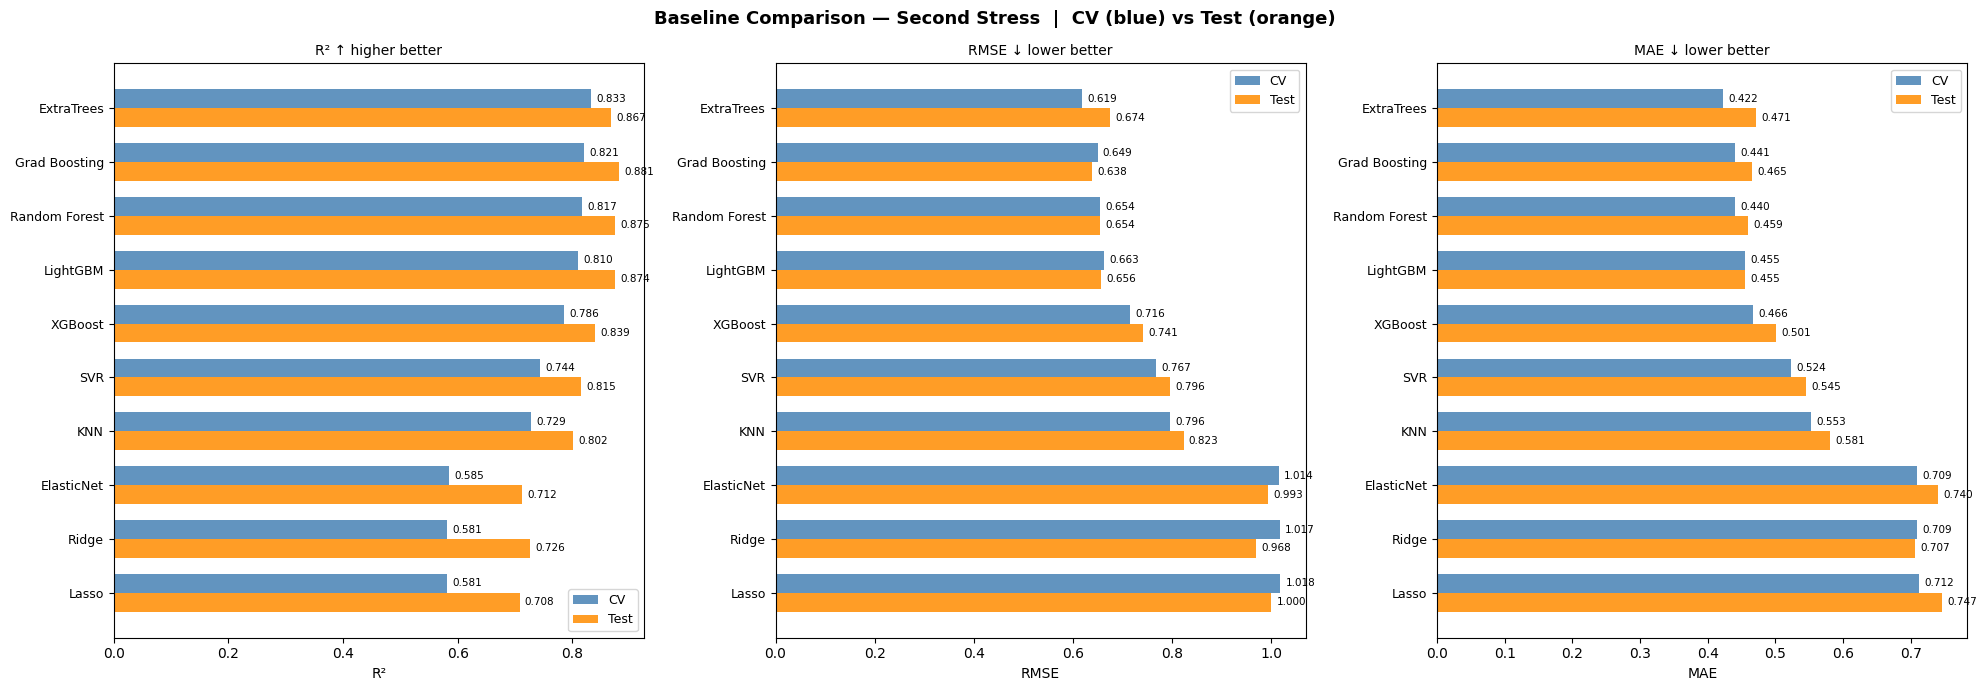

Saved: metrics_stress.png


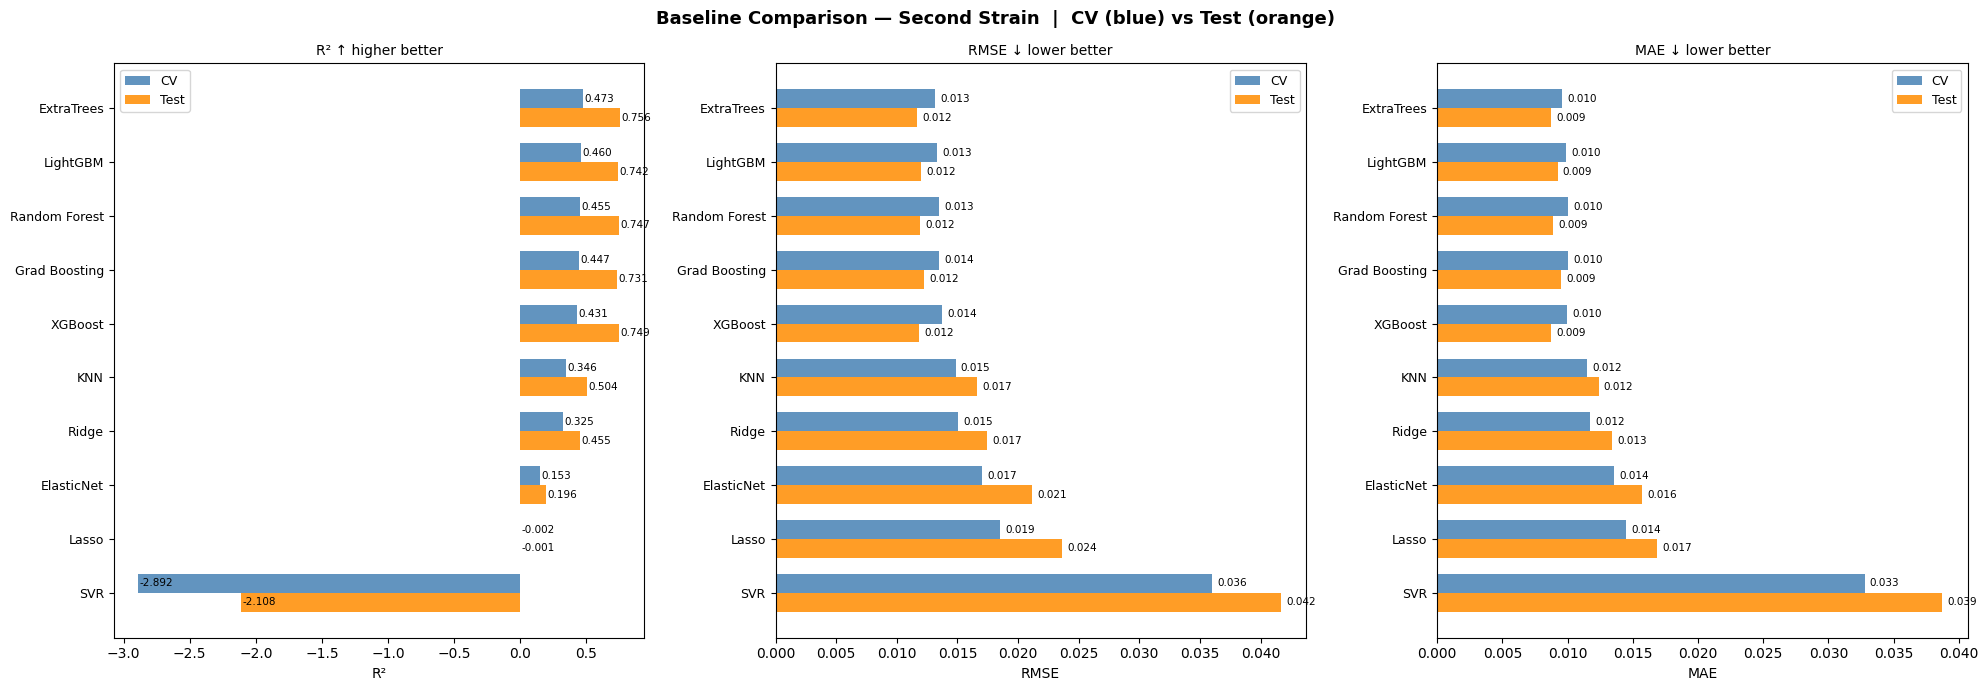

Saved: metrics_strain.png


In [11]:
def plot_all_metrics(cv_res, test_res, target_name, filename):
    """3-metric comparison: CV R², CV RMSE, CV MAE + test overlay."""

    # Merge CV and test on Model
    merged = cv_res.merge(test_res[['Model','Test R²','Test RMSE','Test MAE']],
                          on='Model', how='left')
    merged = merged.sort_values('CV R²', ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(f'Baseline Comparison — {target_name}  |  CV (blue) vs Test (orange)',
                 fontsize=13, fontweight='bold')

    metrics = [
        ('CV R²',   'Test R²',   'R²',           True ),   # higher better
        ('CV RMSE', 'Test RMSE', 'RMSE',          False),   # lower better
        ('CV MAE',  'Test MAE',  'MAE',           False),   # lower better
    ]

    for ax, (cv_col, test_col, label, higher_better) in zip(axes, metrics):
        y      = np.arange(len(merged))
        height = 0.35

        cv_vals   = merged[cv_col].fillna(0).values
        test_vals = merged[test_col].fillna(0).values

        bars_cv   = ax.barh(y + height/2, cv_vals,   height, label='CV',   color='steelblue',  alpha=0.85)
        bars_test = ax.barh(y - height/2, test_vals, height, label='Test', color='darkorange', alpha=0.85)

        ax.set_yticks(y)
        ax.set_yticklabels(merged['Model'], fontsize=9)
        ax.set_xlabel(label, fontsize=10)
        ax.set_title(label + (' ↑ higher better' if higher_better else ' ↓ lower better'),
                     fontsize=10)
        ax.legend(fontsize=9)

        # Add value labels
        for bar, val in zip(bars_cv, cv_vals):
            if not np.isnan(val) and abs(val) < 10:
                ax.text(val + ax.get_xlim()[1]*0.01,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.3f}', va='center', fontsize=7.5)
        for bar, val in zip(bars_test, test_vals):
            if not np.isnan(val) and abs(val) < 10:
                ax.text(val + ax.get_xlim()[1]*0.01,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.3f}', va='center', fontsize=7.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_all_metrics(results_stress, test_stress, 'Second Stress',       'metrics_stress.png')
plot_all_metrics(results_strain, test_strain, 'Second Strain',       'metrics_strain.png')

In [12]:
print("\n" + "=" * 70)
print("  COMPLETE RESULTS TABLE — SECOND STRESS")
print("=" * 70)

stress_full = results_stress.merge(
    test_stress[['Model','Test R²','Test RMSE','Test MAE']], on='Model', how='left'
).sort_values('CV R²', ascending=False)

print(f"\n  {'Model':<20} {'CV R²':>8} {'CV RMSE':>10} {'CV MAE':>10} "
      f"{'Test R²':>10} {'Test RMSE':>12} {'Test MAE':>10}")
print(f"  {'-'*83}")
for _, row in stress_full.iterrows():
    print(f"  {row['Model']:<20} {row['CV R²']:>8.4f} {row['CV RMSE']:>10.4f} "
          f"{row['CV MAE']:>10.4f} {row['Test R²']:>10.4f} "
          f"{row['Test RMSE']:>12.4f} {row['Test MAE']:>10.4f}")

print("\n" + "=" * 70)
print("  COMPLETE RESULTS TABLE — SECOND STRAIN")
print("=" * 70)

strain_full = results_strain.merge(
    test_strain[['Model','Test R²','Test RMSE','Test MAE']], on='Model', how='left'
).sort_values('CV R²', ascending=False)

print(f"\n  {'Model':<20} {'CV R²':>8} {'CV RMSE':>10} {'CV MAE':>10} "
      f"{'Test R²':>10} {'Test RMSE':>12} {'Test MAE':>10}")
print(f"  {'-'*83}")
for _, row in strain_full.iterrows():
    print(f"  {row['Model']:<20} {row['CV R²']:>8.4f} {row['CV RMSE']:>10.4f} "
          f"{row['CV MAE']:>10.4f} {row['Test R²']:>10.4f} "
          f"{row['Test RMSE']:>12.4f} {row['Test MAE']:>10.4f}")




  COMPLETE RESULTS TABLE — SECOND STRESS

  Model                   CV R²    CV RMSE     CV MAE    Test R²    Test RMSE   Test MAE
  -----------------------------------------------------------------------------------
  ExtraTrees             0.8333     0.6187     0.4220     0.8671       0.6744     0.4712
  Grad Boosting          0.8211     0.6495     0.4407     0.8812       0.6375     0.4649
  Random Forest          0.8171     0.6544     0.4398     0.8751       0.6538     0.4593
  LightGBM               0.8096     0.6629     0.4548     0.8743       0.6559     0.4545
  XGBoost                0.7857     0.7159     0.4663     0.8394       0.7413     0.5007
  SVR                    0.7438     0.7674     0.5237     0.8149       0.7959     0.5448
  KNN                    0.7287     0.7955     0.5527     0.8021       0.8229     0.5808
  ElasticNet             0.5847     1.0145     0.7089     0.7118       0.9931     0.7400
  Ridge                  0.5814     1.0166     0.7090     0.7260      

In [13]:
print("\n" + "=" * 70)
print("  METRIC INTERPRETATION GUIDE")
print("=" * 70)
print(f"""
  R²   (R-squared)
       Range: -∞ to 1.0  |  Higher is better  |  1.0 = perfect
       What it means: % of variance in the target explained by the model
       Rule of thumb: >0.85 = excellent, 0.70-0.85 = good, <0.70 = weak

  RMSE (Root Mean Squared Error)
       Range: 0 to ∞     |  Lower is better   |  Same units as target
       What it means: Average prediction error, penalises large errors heavily
       For Stress: RMSE of 0.65 means avg error of ±0.65 MPa
       For Strain: RMSE of 0.012 means avg error of ±0.012 strain units

  MAE  (Mean Absolute Error)
       Range: 0 to ∞     |  Lower is better   |  Same units as target
       What it means: Average absolute prediction error, treats all errors equally
       More robust to outliers than RMSE
       For Stress: MAE of 0.46 means model is typically off by 0.46 MPa

  KEY INSIGHT — CV vs Test gap:
       Small gap  → model generalises well, stable
       Large gap  → possible overfitting or unlucky test split
       Test > CV  → usually fine, model benefits from full training data
""")

print("✅ Full baseline comparison complete.")
print("   Top candidates for tuning: ExtraTrees, Random Forest, Grad Boosting")
print("   (+ XGBoost and LightGBM when available)")

# Save full results to CSV
stress_full.to_csv('results_stress_full.csv', index=False)
strain_full.to_csv('results_strain_full.csv', index=False)
print("\nSaved: results_stress_full.csv")
print("Saved: results_strain_full.csv")



  METRIC INTERPRETATION GUIDE

  R²   (R-squared)
       Range: -∞ to 1.0  |  Higher is better  |  1.0 = perfect
       What it means: % of variance in the target explained by the model
       Rule of thumb: >0.85 = excellent, 0.70-0.85 = good, <0.70 = weak

  RMSE (Root Mean Squared Error)
       Range: 0 to ∞     |  Lower is better   |  Same units as target
       What it means: Average prediction error, penalises large errors heavily
       For Stress: RMSE of 0.65 means avg error of ±0.65 MPa
       For Strain: RMSE of 0.012 means avg error of ±0.012 strain units

  MAE  (Mean Absolute Error)
       Range: 0 to ∞     |  Lower is better   |  Same units as target
       What it means: Average absolute prediction error, treats all errors equally
       More robust to outliers than RMSE
       For Stress: MAE of 0.46 means model is typically off by 0.46 MPa

  KEY INSIGHT — CV vs Test gap:
       Small gap  → model generalises well, stable
       Large gap  → possible overfitting or u

In [15]:
def objective_et(trial, X_tr, y_tr):
    model = ExtraTreesRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_int('max_depth', 5, 30),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=42, n_jobs=-1
    )
    return cv_score(model, X_tr, y_tr)

def objective_rf(trial, X_tr, y_tr):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_int('max_depth', 5, 30),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=42, n_jobs=-1
    )
    return cv_score(model, X_tr, y_tr)

def objective_gb(trial, X_tr, y_tr):
    model = GradientBoostingRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 2, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        random_state=42
    )
    return cv_score(model, X_tr, y_tr)

def objective_xgb(trial, X_tr, y_tr):
    model = XGBRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        objective='reg:squarederror', random_state=42, verbosity=0
    )
    return cv_score(model, X_tr, y_tr)

def objective_lgb(trial, X_tr, y_tr):
    model = LGBMRegressor(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        max_depth         = trial.suggest_int('max_depth', 3, 15),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 20, 150),
        random_state=42, verbose=-1
    )
    return cv_score(model, X_tr, y_tr)

In [17]:
def build_model(name, params):
    if name == "ExtraTrees":
        return ExtraTreesRegressor(**params, random_state=42, n_jobs=-1)
    elif name == "RandomForest":
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    elif name == "GradBoosting":
        return GradientBoostingRegressor(**params, random_state=42)
    elif name == "XGBoost":
        return XGBRegressor(**params, random_state=42, verbosity=0,
                            objective='reg:squarederror')
    elif name == "LightGBM":
        return LGBMRegressor(**params, random_state=42, verbose=-1)

def full_train_predict(X_tr, X_te, y_tr, y_te, model, is_log=False):
    """Train on full training set with target encoding, predict on test."""
    te     = TargetEncoder(cols=['Fiber Type'], smoothing=10)
    X_enc_tr = te.fit_transform(X_tr.copy(), y_tr)
    X_enc_te = te.transform(X_te.copy())

    scaler   = StandardScaler()
    X_sc_tr  = scaler.fit_transform(X_enc_tr)
    X_sc_te  = scaler.transform(X_enc_te)

    model.fit(X_sc_tr, y_tr)
    pred = model.predict(X_sc_te)

    if is_log:
        pred   = np.expm1(pred)
        y_orig = np.expm1(y_te)
    else:
        y_orig = y_te

    return y_orig, pred

print("\n" + "=" * 65)
print("  TEST SET RESULTS — TUNED MODELS")
print("=" * 65)

test_results = []
for target_name, y_tr, y_te, is_log in [
    ("Stress", ys_train, ys_test, False),
    ("Strain", yt_train, yt_test, True),
]:
    print(f"\n  {'-'*60}")
    print(f"  Second {target_name}")
    print(f"  {'Model':<20} {'CV R²':>8} {'Test R²':>10} {'RMSE':>10} {'MAE':>10}")
    print(f"  {'-'*60}")

    # Get baseline CV R² for comparison
    baseline_cv = {r['Model']: r['Best CV R²'] for r in tuning_summary
                   if r['Target'] == target_name}

    for job in tuning_summary:
        if job['Target'] != target_name:
            continue

        model_name = job['Model']
        key        = f"{model_name}_{target_name}"
        params     = best_params[key]
        model      = build_model(model_name, params)

        y_orig, pred = full_train_predict(
            X_train, X_test, y_tr, y_te, model, is_log
        )

        r2   = r2_score(y_orig, pred)
        rmse = np.sqrt(mean_squared_error(y_orig, pred))
        mae  = mean_absolute_error(y_orig, pred)
        cv   = job['Best CV R²']

        print(f"  {model_name:<20} {cv:>8.4f} {r2:>10.4f} {rmse:>10.4f} {mae:>10.4f}")
        test_results.append({
            'Model'     : model_name,
            'Target'    : target_name,
            'CV R²'     : cv,
            'Test R²'   : round(r2,   4),
            'Test RMSE' : round(rmse, 6),
            'Test MAE'  : round(mae,  6),
        })


  TEST SET RESULTS — TUNED MODELS

  ------------------------------------------------------------
  Second Stress
  Model                   CV R²    Test R²       RMSE        MAE
  ------------------------------------------------------------


NameError: name 'tuning_summary' is not defined